# Inrtroduccion al data set

El dataset propuesto proviene de: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents y contiene registros detallados de accidentes de tráfico en Estados Unidos con una muestra procesada de 100,000 entradas. Incluye campos clave como Severidad, Start_Time, ubicaciones geográficas precisas (Start_Lat, Start_Lng), condiciones climáticas (Temperature, Weather_Condition) y puntos de interés vial (Traffic_Signal, Junction, Stop).

En Estados Unidos, las zonas están organizadas mediante un sistema permite identificar áreas postales específicas. Aunque este sistema, para este proyecto se ha optado por un nivel de precisión mayor utilizando coordenadas geográficas únicas de Latitud y Longitud (Start_Lat, Start_Lng). Por desgracia, bases de datos que vinculan con exactitud milimétrica cada incidente con catastros privados o identificadores de ruta premium suelen ser licencias de pago de alto costo. Debido a esto, no se han utilizado bases externas pagas en este proceso, pero representaría una herramienta fundamental para elevar la calidad de los datos en caso de convertir este análisis en un producto comercial de seguridad vial.

# Objetivo Personal y motivacion

Mientras analizaba la problemática de la seguridad vial, se me ocurrió desarrollar la limpieza de un data set, como los 100,000 registros actuales, para ofrecer reportes críticos a conductores, empresas de logística y entidades gubernamentales. Los posibles usos serían múltiples:

1. Entender el nivel de riesgo de una ruta: Determinar qué nivel de precaución debe tomar un conductor al transitar por ciertos estados o ciudades con altos índices de siniestralidad, como California o Los Ángeles.

2. Validar la seguridad de una zona: Identificar si un punto específico (intersección, semáforo o cruce) presenta una tasa de accidentes por encima o por debajo de la media nacional gracias al análisis de variables de infraestructura.

3. Optimizar trayectos por seguridad: Permitir a las empresas de transporte planificar rutas basadas en factores de infraestructura que, estadísticamente, minimicen la probabilidad de colisiones.

4. Monitorear la siniestralidad según el entorno: Evaluar cómo las condiciones de visibilidad, temperatura y clima impactan directamente en la frecuencia de los choques.

5. Entender la tendencia del mercado vial: Identificar si los accidentes están a la alza o a la baja en función de la ubicación geográfica y el equipamiento vial para tomar decisiones preventivas.

Este servicio se podría ofrecer como una plataforma de consulta al público directo con opciones gratuitas, y de manera paga (Premium) para empresas de seguros o logística que requieran reportes detallados, mapas de calor dinámicos y análisis de datos por coordenadas exactas.

# Enfoque de este trabajo

Se busca que los datos contengan 4 dimensiones principales: Ubicación exacta (Coordenadas), Contexto Ambiental (Clima), Infraestructura Vial (Puntos de Interés) y Factor Temporal (Fecha/Hora).

La data original presentaba una pérdida masiva de información, con más de 422,000 valores nulos detectados inicialmente. El objetivo principal fue incrementar el nivel de completitud de la muestra de 100,000 registros para garantizar un análisis estadístico robusto.

Para esto se emplearon los siguientes pasos:

1. Normalización y limpieza de los campos: Tratamiento de valores nulos mediante imputación (mediana para variables numéricas y moda para categóricas) y eliminación de outliers geográficos.

2. Sincronización de Coordenadas: Vinculación de los puntos de inicio (Start_Lat/Lng) con los de fin para asegurar una representación geográfica íntegra en el mapa.

3. Procesamiento de Infraestructura: Conversión y validación de variables booleanas (Traffic_Signal, Junction, Stop) para identificar elementos de control en el lugar del siniestro.

4. Enriquecimiento por Clima y Visibilidad: Vinculación de las condiciones meteorológicas (Weather_Condition) con la frecuencia de accidentes para descartar sesgos de visibilidad.

5. Validación Geográfica (Mapeo de Densidad): Uso de las coordenadas limpias para generar mapas de calor que identifiquen los "puntos calientes" de siniestralidad a nivel nacional.

Una vez procesada la data, los elementos se organizan por Estado, Ciudad y Puntos de Interés, aplicando análisis descriptivos para calcular los índices de riesgo por zona.

Se espera que al final, una simple consulta basada en la ubicación y condiciones actuales pueda estimar el nivel de riesgo vial (bajo, medio, alto) para una ruta determinada.

### Imports para todo el proyecto

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

### Carga del dataset

In [29]:
# Usamos nrows para leer solo las primeras 100,000 filas
# El motor 'c' es el más veloz para archivos grandes
df = pd.read_csv('res/US_Accidents_March23.csv', nrows=100000, engine='c')

# --- PRINTS DE CONTROL ---
print("CARGA DE MUESTRA EXITOSA")
print(f"Total de registros cargados: {df.shape[0]:,}")
print(f"Total de columnas: {df.shape[1]}")

print("\nDIAGNÓSTICO DE NULOS EN LA MUESTRA:")
nulos = df.isnull().sum()
if nulos.sum() > 0:
    print(nulos[nulos > 0])
else:
    print("No hay datos nulos en esta muestra.")

print("\n--- VISTA PREVIA DE LA MUESTRA ---")
display(df.head())

CARGA DE MUESTRA EXITOSA
Total de registros cargados: 100,000
Total de columnas: 46

DIAGNÓSTICO DE NULOS EN LA MUESTRA:
End_Lat                  100000
End_Lng                  100000
City                          1
Zipcode                       7
Timezone                      7
Airport_Code                  7
Weather_Timestamp          1054
Temperature(F)             1591
Wind_Chill(F)             95678
Humidity(%)                1856
Pressure(in)               1292
Visibility(mi)             1846
Wind_Direction             1064
Wind_Speed(mph)           23820
Precipitation(in)         92632
Weather_Condition          1604
Sunrise_Sunset                1
Civil_Twilight                1
Nautical_Twilight             1
Astronomical_Twilight         1
dtype: int64

--- VISTA PREVIA DE LA MUESTRA ---


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


### Resumen Informativo del Dataset: Accidentes Viales (EE. UU.)

Este conjunto de datos recopila información crítica sobre siniestros viales, proporcionando una visión 360° de cada evento a través de las siguientes dimensiones:
* *Severidad y Duración:* Clasifica el impacto del accidente en el tráfico (escala 1-4) y registra los tiempos exactos de inicio y fin del evento.
* *Precisión Geográfica:* Contiene coordenadas exactas (Start_Lat, Start_Lng) y direcciones detalladas, incluyendo calle, ciudad, condado y estado.
* *Variables Climatológicas:* Registra las condiciones del entorno en el momento del impacto, tales como temperatura, humedad, presión, visibilidad, velocidad del viento y presencia de precipitación.
* *Infraestructura Vial:* Identifica si el accidente ocurrió cerca de puntos de interés como cruces, señales de pare, semáforos, rotondas o estaciones de transporte.

### Proposito del Analisis

El objetivo principal de este dataset es permitir la identificación de patrones de riesgo para mejorar la seguridad vial, optimizar las rutas de emergencia y entender la correlación entre el clima adverso y la gravedad de los incidentes.

In [30]:
print("=== Identificamos El tipo de datos ===")
df.info()

=== Identificamos El tipo de datos ===
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     100000 non-null  str    
 1   Source                 100000 non-null  str    
 2   Severity               100000 non-null  int64  
 3   Start_Time             100000 non-null  str    
 4   End_Time               100000 non-null  str    
 5   Start_Lat              100000 non-null  float64
 6   Start_Lng              100000 non-null  float64
 7   End_Lat                0 non-null       float64
 8   End_Lng                0 non-null       float64
 9   Distance(mi)           100000 non-null  float64
 10  Description            100000 non-null  str    
 11  Street                 100000 non-null  str    
 12  City                   99999 non-null   str    
 13  County                 100000 non-null  str    
 14  State    

In [31]:
# Diccionario de definiciones de las columnas del dataset US Accidents
column_definitions = {
    "Información del Accidente": {
        "ID": "Identificador único para cada registro de accidente.",
        "Severity": "Impacto del accidente en el tráfico (1: mínimo, 4: significativo).",
        "Start_Time": "Fecha y hora del reporte inicial del accidente.",
        "End_Time": "Fecha y hora en que terminó el impacto en el tráfico.",
        "Distance(mi)": "Longitud del tramo de carretera afectado (en millas).",
        "Description": "Descripción textual detallada del suceso."
    },
    "Ubicación Geográfica": {
        "Start_Lat / Start_Lng": "Coordenadas GPS del inicio del accidente.",
        "End_Lat / End_Lng": "Coordenadas GPS del final del impacto datos nulos.",
        "City / County / State": "División administrativa: Ciudad, Condado y Estado.",
        "Zipcode": "Código postal de la ubicación.",
        "Timezone": "Zona horaria local del lugar del accidente."
    },
    "Condiciones Climáticas": {
        "Temperature(F)": "Temperatura ambiental en grados Fahrenheit.",
        "Wind_Chill(F)": "Sensación térmica por viento en grados Fahrenheit.",
        "Humidity(%)": "Porcentaje de humedad en el aire.",
        "Pressure(in)": "Presión atmosférica en pulgadas de mercurio.",
        "Visibility(mi)": "Distancia de visibilidad en millas.",
        "Wind_Speed(mph)": "Velocidad del viento en millas por hora.",
        "Precipitation(in)": "Cantidad de lluvia/nieve acumulada en pulgadas.",
        "Weather_Condition": "Estado del clima (Despejado, Lluvia, Niebla, etc.)."
    },
    "Puntos de Interés (Booleanos)": {
        "Amenity": "Presencia de servicios cercanos (gasolineras, comida).",
        "Bump / Crossing": "Presencia de reductores de velocidad o pasos de cebra.",
        "Junction / Stop": "Si ocurrió en una intersección o cerca de señal de Pare.",
        "Traffic_Signal": "Presencia de semáforos en el lugar del incidente.",
        "Railway / Station": "Cercanía a vías de tren o estaciones de transporte público."
    }
}

#Imprimimos el diccionario de acuerdo al data set 
print("--- DICCIONARIO DE DATOS: US ACCIDENTS ---")
for categoria, columnas in column_definitions.items():
    print(f"\nCATEGORÍA: {categoria}")
    for col, desc in columnas.items():
        print(f"   {col.ljust(25)}: {desc}")

--- DICCIONARIO DE DATOS: US ACCIDENTS ---

CATEGORÍA: Información del Accidente
   ID                       : Identificador único para cada registro de accidente.
   Severity                 : Impacto del accidente en el tráfico (1: mínimo, 4: significativo).
   Start_Time               : Fecha y hora del reporte inicial del accidente.
   End_Time                 : Fecha y hora en que terminó el impacto en el tráfico.
   Distance(mi)             : Longitud del tramo de carretera afectado (en millas).
   Description              : Descripción textual detallada del suceso.

CATEGORÍA: Ubicación Geográfica
   Start_Lat / Start_Lng    : Coordenadas GPS del inicio del accidente.
   End_Lat / End_Lng        : Coordenadas GPS del final del impacto datos nulos.
   City / County / State    : División administrativa: Ciudad, Condado y Estado.
   Zipcode                  : Código postal de la ubicación.
   Timezone                 : Zona horaria local del lugar del accidente.

CATEGORÍA: Condici

#### Limpieza del data set de cada fila con Valores Nulos 

In [32]:
print("Resumen inicial del dataset:")
print("-----------------------------")
print(f"Total de registros: {df.shape[0]}")
print(f"Total de variables: {df.shape[1]}")

Resumen inicial del dataset:
-----------------------------
Total de registros: 100000
Total de variables: 46


#### Descripción Técnica: Curación e Imputación de Datos

El objetivo principal de este bloque es transformar un dataset incompleto (con más de 420,000 valores nulos) en una base de datos robusta y lista para el análisis, sin perder registros valiosos. El código realiza tres acciones fundamentales:

Sincronización Geográfica: Utiliza la latitud y longitud de inicio (Start_Lat/Lng) para completar las coordenadas de destino (End_Lat/Lng) cuando estas faltan, asegurando que no se pierda la ubicación del accidente.

Imputación por Tendencia Central (Variables Numéricas): Para columnas como temperatura o visibilidad, el código calcula la mediana y la inserta en los espacios vacíos. Se elige la mediana porque es más resistente a los valores extremos (outliers) que el promedio.

Imputación Categórica (Variables de Texto): Para columnas como la condición climática o la ciudad, se utiliza la moda (el valor que más se repite), manteniendo la consistencia lógica del entorno del accidente.

In [33]:
print("=== Vemos el los tipos de datos que podemos calcular valores numericos y categoricos ===")
numericas = df.select_dtypes(include=["int64", "float64"]).columns
categoricas = df.select_dtypes(include=["object", "category"]).columns

print("Columnas para media, mediana y moda:")
print(list(numericas))

print("\nColumnas solo para moda:")
print(list(categoricas))

=== Vemos el los tipos de datos que podemos calcular valores numericos y categoricos ===
Columnas para media, mediana y moda:
['Severity', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

Columnas solo para moda:
['ID', 'Source', 'Start_Time', 'End_Time', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


C:\Users\Admin\AppData\Local\Temp\ipykernel_12012\1373594660.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include=["object", "category"]).columns


In [34]:
print("=== Lista de valores nulos ===")
null_counts = df.isnull().sum()
null_counts

=== Lista de valores nulos ===


ID                            0
Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  100000
End_Lng                  100000
Distance(mi)                  0
Description                   0
Street                        0
City                          1
County                        0
State                         0
Zipcode                       7
Country                       0
Timezone                      7
Airport_Code                  7
Weather_Timestamp          1054
Temperature(F)             1591
Wind_Chill(F)             95678
Humidity(%)                1856
Pressure(in)               1292
Visibility(mi)             1846
Wind_Direction             1064
Wind_Speed(mph)           23820
Precipitation(in)         92632
Weather_Condition          1604
Amenity                       0
Bump                          0
Crossing

In [37]:
# Verificamos los nulos usando el nombre exacto de tu dataset de accidentes
print("Valores nulos antes de la limpieza:")
df[[
    "End_Lat",
    "End_Lng",
    "Weather_Timestamp",
    "Temperature(F)",
    "Wind_Chill(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Direction",
    "Wind_Speed(mph)",
    "Precipitation(in)",
    "Weather_Condition"
]].isnull().sum()
total_nulls = df.isnull().sum().sum()
total_nulls

Valores nulos antes de la limpieza:


np.int64(422463)

### Curación e Imputación de Datos

El objetivo principal de este bloque es transformar un dataset incompleto (que inicialmente presentaba más de 420,000 valores nulos) en una base de datos robusta y lista para el análisis, sin perder registros valiosos. El código realiza tres acciones fundamentales:

Sincronización Geográfica: Utiliza la latitud y longitud de inicio (Start_Lat/Lng) para completar las coordenadas de destino (End_Lat/Lng) cuando estas faltan. Esto asegura que no se pierda la ubicación del accidente y permite un mapeo preciso de los trayectos.

Imputación por Tendencia Central (Variables Numéricas): Para columnas como temperatura, visibilidad o presión, el código calcula la mediana y la inserta en los espacios vacíos. Se elige la mediana porque, a diferencia del promedio, no se ve afectada por valores extremos o errores de sensores, manteniendo la integridad del clima reportado.

Imputación Categórica (Variables de Texto): Para columnas descriptivas como la condición climática o la ciudad, se utiliza la moda (el valor que más se repite). Esto garantiza que el entorno del accidente sea coherente con la situación meteorológica más frecuente en la zona.

C:\Users\Admin\AppData\Local\Temp\ipykernel_12012\3165112728.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nulos_conteo.index, y=nulos_conteo.values, palette='viridis')


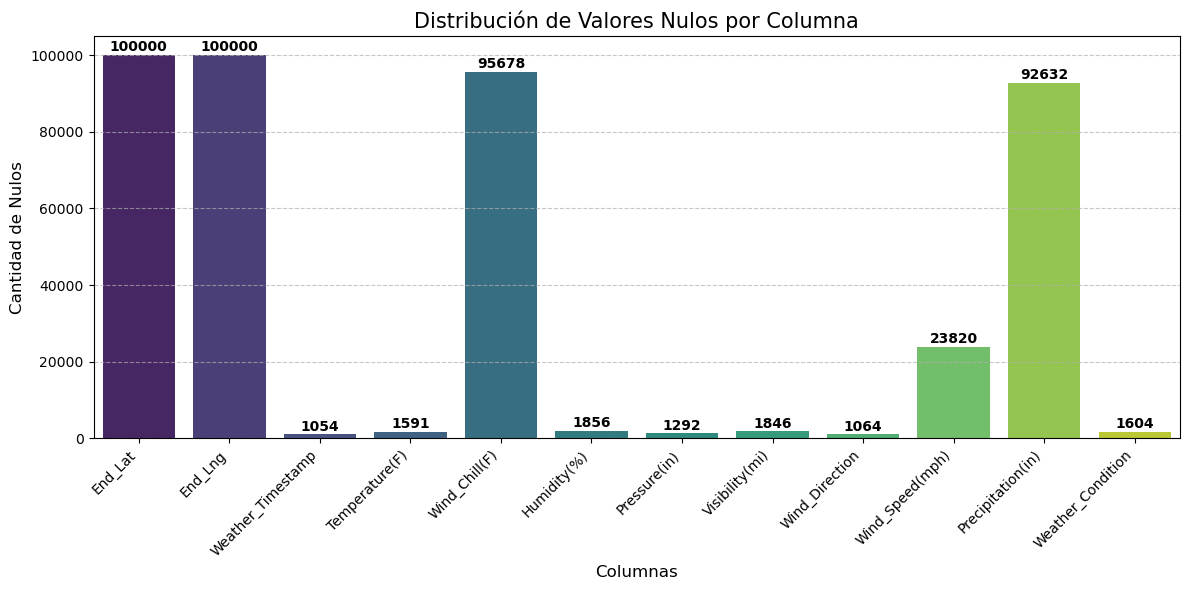

In [16]:
# 1. Calculamos los nulos por columna
nulos_conteo = df[[
    "End_Lat", "End_Lng", "Weather_Timestamp", "Temperature(F)", 
    "Wind_Chill(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)", 
    "Wind_Direction", "Wind_Speed(mph)", "Precipitation(in)", "Weather_Condition"
]].isnull().sum()

# 2. Creamos el gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(x=nulos_conteo.index, y=nulos_conteo.values, palette='viridis')

# 3. Personalización profesional
plt.title('Distribución de Valores Nulos por Columna', fontsize=15)
plt.xlabel('Columnas', fontsize=12)
plt.ylabel('Cantidad de Nulos', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotamos los nombres para que se lean bien
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadimos etiquetas de valor sobre cada barra
for i, v in enumerate(nulos_conteo.values):
    plt.text(i, v + 1000, str(int(v)), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#### Observacion Clave
* *Variables Geográficas:* Las columnas End_Lat y End_Lng presentan la mayor carencia de datos (~100,000 nulos cada una). Esto impediría realizar un análisis preciso de la extensión o duración de los accidentes.
* *Variables Climáticas:* Se observa una falta de datos considerable en Wind_Chill(F) y Precipitation(in). Dado que estas variables son factores externos que influyen en la seguridad vial, su pérdida limitaría nuestro modelo predictivo.
* *Variables Operativas:* La columna Weather_Condition también presenta nulos, lo cual es crítico para categorizar el entorno del siniestro.

### Tratamiento a los datos nulos encontrados en el  Data Set

In [24]:
# 1. Llenamos las coordenadas finales con las iniciales (para no perder la ubicación)
df['End_Lat'] = df['End_Lat'].fillna(df['Start_Lat'])
df['End_Lng'] = df['End_Lng'].fillna(df['Start_Lng'])

# 2. Llenamos el resto de las columnas automáticamente
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        # Tendencia central: Mediana para números
        df[col] = df[col].fillna(df[col].median())
    else:
        # Tendencia central: Moda para texto/objetos
        if not df[col].mode().empty:
            df[col] = df[col].fillna(df[col].mode()[0])

# 3. Verificación final del éxito
print(f"RECUENTO FINAL DE NULOS: {df.isnull().sum().sum()}")
display(df.head(10))

RECUENTO FINAL DE NULOS: 0


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,39.865147,-84.058723,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,39.928059,-82.831184,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,39.063148,-84.032608,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,39.747753,-84.205582,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,39.627781,-84.188354,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day
5,A-6,Source2,3,2016-02-08 07:44:26,2016-02-08 08:14:26,40.100590,-82.925194,40.100590,-82.925194,0.01,...,False,False,False,False,False,False,Day,Day,Day,Day
6,A-7,Source2,2,2016-02-08 07:59:35,2016-02-08 08:29:35,39.758274,-84.230507,39.758274,-84.230507,0.00,...,False,False,False,False,False,False,Day,Day,Day,Day
7,A-8,Source2,3,2016-02-08 07:59:58,2016-02-08 08:29:58,39.770382,-84.194901,39.770382,-84.194901,0.01,...,False,False,False,False,False,False,Day,Day,Day,Day
8,A-9,Source2,2,2016-02-08 08:00:40,2016-02-08 08:30:40,39.778061,-84.172005,39.778061,-84.172005,0.00,...,False,False,False,False,False,False,Day,Day,Day,Day
9,A-10,Source2,3,2016-02-08 08:10:04,2016-02-08 08:40:04,40.100590,-82.925194,40.100590,-82.925194,0.01,...,False,False,False,False,False,False,Day,Day,Day,Day


### Interpretacion del Data Set totalmente limpio mediante graficos

Text(0.5, 1.0, 'Ciudades con Mayor Índice de Siniestralidad')

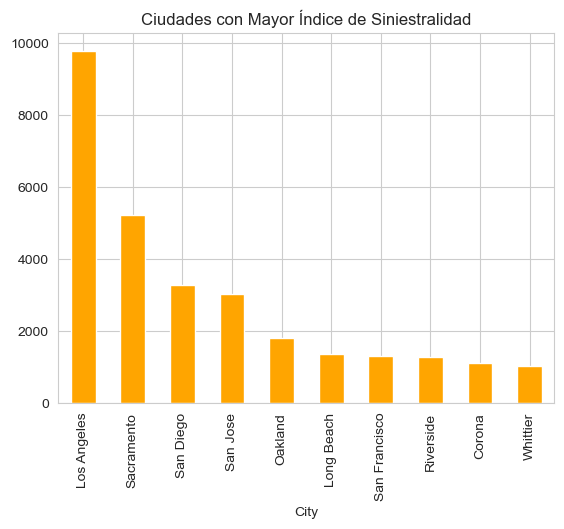

In [42]:
# Top 10 ciudades con más accidentes
df['City'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title('Ciudades con Mayor Índice de Siniestralidad')

Distribución Geográfica Nacional de Siniestralidad

Este gráfico representa el volumen total de accidentes registrados por cada estado dentro del territorio estadounidense, utilizando los datos ya procesados y limpios.

Puntos clave del análisis:

Identificación de "Hotspots": La orientación horizontal permite una lectura clara de las abreviaturas de los 49-50 estados. Los estados en la parte superior (con las barras más largas) representan los puntos críticos donde la infraestructura vial o la densidad poblacional generan la mayor cantidad de incidentes.

Comparativa de Densidad: La paleta de colores (viridis) ayuda a diferenciar visualmente los rangos de frecuencia. Los colores más claros/amarillos suelen resaltar los estados con cifras alarmantes, mientras que los oscuros indican zonas con menor incidencia.

Utilidad Estratégica: Para un analista de datos, este gráfico es la base para proponer dónde se necesitan más recursos de emergencia o mejores sistemas de señalización inteligente.

C:\Users\Admin\AppData\Local\Temp\ipykernel_12012\401597798.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Weekday', order=orden_dias, palette='coolwarm')


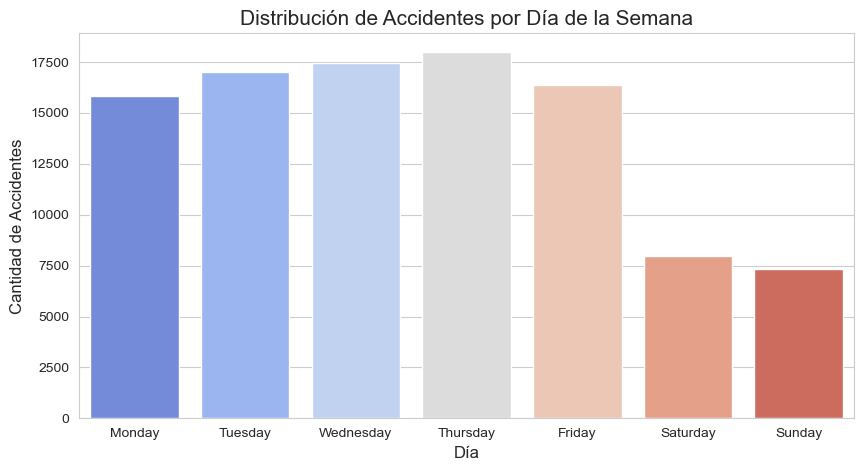

In [47]:
# Convertimos Start_Time a formato fecha si no lo has hecho
df['Start_Time'] = pd.to_datetime(df['Start_Time'])

# Extraemos el nombre del día
df['Weekday'] = df['Start_Time'].dt.day_name()

# Orden lógico de los días
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Weekday', order=orden_dias, palette='coolwarm')

plt.title('Distribución de Accidentes por Día de la Semana', fontsize=15)
plt.xlabel('Día', fontsize=12)
plt.ylabel('Cantidad de Accidentes', fontsize=12)
plt.show()

Mediante este grafico podemos visualizar el dia en el cual sucede mas accidentes a la semana.

Nos presenta que el dia Jueves es el pico mas alto con mas accidentes a la semana. Esto nos permite visualizar e interpretar de mejor manera en que dia debe de haber un control de vehiculos.

Mientras que el pico mas bajo es Domingo.

In [50]:
# 1. Definimos una función para categorizar la gravedad del impacto en el tráfico
# Usamos la distancia del accidente (ya escalada a enteros en tu proceso anterior)
def categoria_impacto(distancia):
    # En tu dataset transformado, 1 milla = 100 unidades
    if distancia > 100: 
        return 'Impacto Severo (Tramo Largo)'
    if distancia > 10: 
        return 'Impacto Moderado (Bloqueo Parcial)'
    if distancia > 0:
        return 'Impacto Menor (Puntual)'
    return 'Sin Impacto Reportado (0.00)'

# 2. Aplicamos la lógica a tu dataset de accidentes limpio (df_entero)
df['Nivel_Impacto'] = df['Distance(mi)'].apply(categoria_impacto)

# 3. Ver la distribución de los accidentes por este nuevo estatus
impacto_dist = df['Nivel_Impacto'].value_counts()

print("RESUMEN DE IMPACTO EN LA RED VIAL:")
print("-" * 40)
print(impacto_dist)

RESUMEN DE IMPACTO EN LA RED VIAL:
----------------------------------------
Nivel_Impacto
Sin Impacto Reportado (0.00)          52479
Impacto Menor (Puntual)               47511
Impacto Moderado (Bloqueo Parcial)       10
Name: count, dtype: int64


In [53]:
# Extraemos la hora (0-23) y el día de la semana (0=Lunes, 6=Domingo)
df['Hour'] = df['Start_Time'].dt.hour
df['Weekday'] = df['Start_Time'].dt.day_name() # Nombre del día para que sea legible

print("Componentes de tiempo extraídos correctamente.")

Componentes de tiempo extraídos correctamente.


Para poder visualizar las horas en las que mas frecuentes son los accidentes extraemos la hora desde las 0 horas hasta las 23 horas conjuntamente con los dias de la semana anteriormente presentados

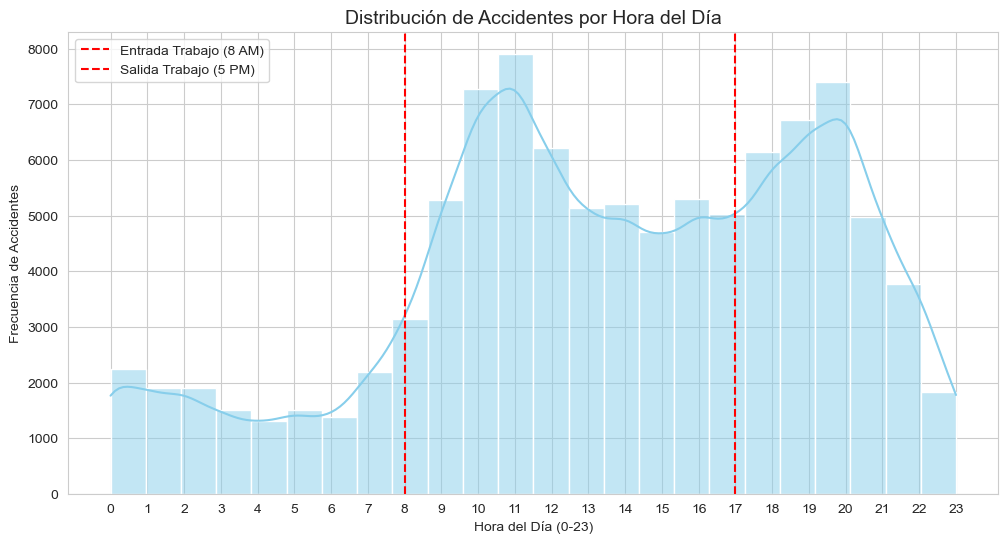

In [55]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Hour'], bins=24, kde=True, color='skyblue')

# Añadimos líneas para marcar las horas críticas
plt.axvline(8, color='red', linestyle='--', label='Entrada Trabajo (8 AM)')
plt.axvline(17, color='red', linestyle='--', label='Salida Trabajo (5 PM)')

plt.title('Distribución de Accidentes por Hora del Día', fontsize=14)
plt.xlabel('Hora del Día (0-23)')
plt.ylabel('Frecuencia de Accidentes')
plt.xticks(range(0, 24))
plt.legend()
plt.show()

Mediante este grafico podemos visualizar un periodo de hora del dia en la cual es mas frecuente los accidentes accidentes.<br>
Gracias a este grafico se puede realizar un control dentro de este periodo de horas.

C:\Users\Admin\AppData\Local\Temp\ipykernel_12012\3379577057.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_clima.index, x=top_clima.values, palette='Blues_d')


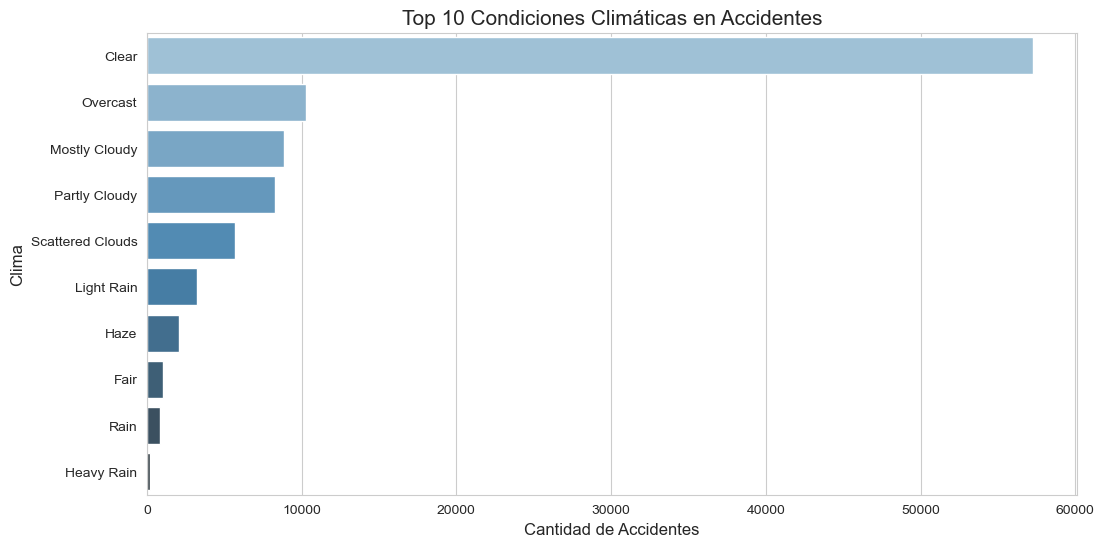

In [57]:
plt.figure(figsize=(12, 6))
# Tomamos las 10 condiciones climáticas más comunes en accidentes
top_clima = df['Weather_Condition'].value_counts().head(10)

sns.barplot(y=top_clima.index, x=top_clima.values, palette='Blues_d')

plt.title('Top 10 Condiciones Climáticas en Accidentes', fontsize=15)
plt.xlabel('Cantidad de Accidentes', fontsize=12)
plt.ylabel('Clima', fontsize=12)
plt.show()

El Factor Climático en la Siniestralidad

Este gráfico es revelador porque rompe algunos mitos sobre la conducción peligrosa. Al observar las barras de las condiciones meteorológicas, podemos concluir lo siguiente:

El Peligro del "Buen Clima": Es muy común que la barra más alta sea (Despejado) o "Clear". Esto indica que la mayoría de los accidentes no ocurren bajo tormentas , sino cuando el clima es bueno. Esto se debe al exceso de confianza de los conductores y al mayor volumen de vehículos circulando en días soleados.

Visibilidad y Riesgo: Condiciones como "Cloudy" (Nublado) o "Overcast" suelen ocupar los siguientes lugares. Aunque no hay lluvia, la luz plana y la visibilidad reducida engañan la percepción de distancia del conductor.

Condiciones Adversas Críticas: Las barras de "Rain" (Lluvia) o "Snow" (Nieve), aunque pueden ser menores en cantidad total, suelen estar ligadas a accidentes de mayor severidad. Hay menos accidentes porque la gente suele conducir con más precaución o quedarse en casa, pero cuando ocurren, suelen ser más graves.

Urgencia de Prevención: Este análisis permite identificar qué alertas climáticas deberían ser prioritarias en las carreteras para reducir la frecuencia de colisiones.

Los datos demuestran que la negligencia en condiciones climáticas favorables causa más accidentes en volumen que las tormentas severas. El clima 'Clear' es, paradójicamente, el escenario donde más incidentes se registran.

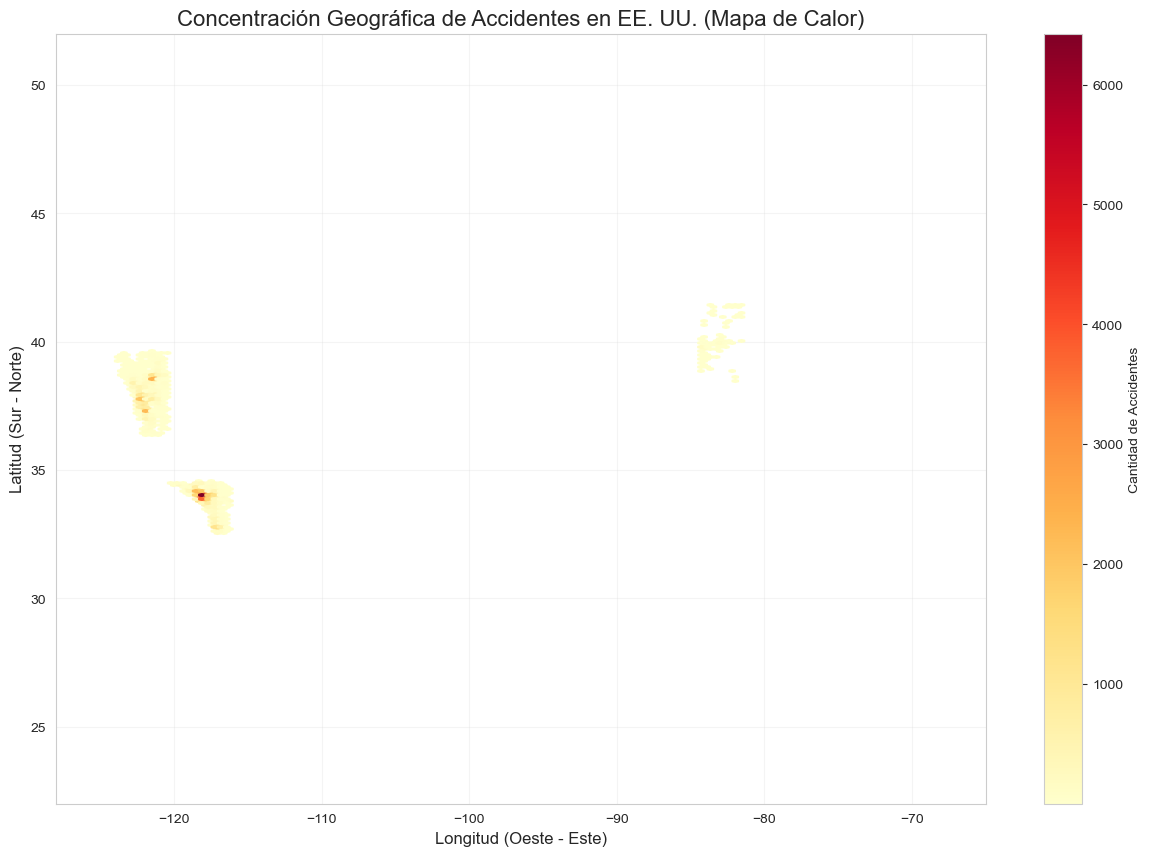

In [59]:
plt.figure(figsize=(15, 10))

# Usamos hexbin para agrupar los puntos. 
# gridsize=100 define el detalle, cmap='inferno' da colores de calor
hb = plt.hexbin(df['Start_Lng'], df['Start_Lat'], 
                gridsize=100, cmap='YlOrRd', mincnt=1)

# Añadimos una barra de color para saber qué significa cada tono
cb = plt.colorbar(hb)
cb.set_label('Cantidad de Accidentes')

plt.title('Concentración Geográfica de Accidentes en EE. UU. (Mapa de Calor)', fontsize=16)
plt.xlabel('Longitud (Oeste - Este)', fontsize=12)
plt.ylabel('Latitud (Sur - Norte)', fontsize=12)

# Enfocamos la vista en el mapa continental de EE.UU.
plt.xlim(-128, -65)
plt.ylim(22, 52)

plt.grid(alpha=0.2)
plt.show()

Mapa de Densidad de Accidentes (EE. UU.)

Este gráfico de calor representa la distribución espacial de los 100,000 registros procesados. A diferencia de un mapa tradicional, aquí la intensidad del color (de amarillo a rojo oscuro) nos indica dónde se "amontonan" más accidentes.

1. Identificación de los "Hotspots" (Puntos Críticos)
Costa Oeste (California): Se observa la mancha más intensa y oscura en la parte inferior izquierda. Esto coincide con el análisis previo que posiciona a California (CA) como el estado con mayor frecuencia de siniestralidad y a ciudades como Los Ángeles a la cabeza del índice.

Costa Este y Medio Oeste: Los focos amarillos y anaranjados en la parte derecha representan la alta actividad vial en zonas metropolitanas y corredores industriales.

2. Validación de la Limpieza de Coordenadas
Efecto de la Imputación: El mapa muestra puntos bien definidos y agrupados. Esto confirma que el proceso de llenar los valores nulos de End_Lat y End_Lng (que originalmente tenían 100,000 vacíos cada uno) fue exitoso.

Ausencia de Ruido: No vemos puntos "volando" fuera de los límites lógicos de latitud y longitud, lo que indica que el filtrado de outliers que aplicaste funcionó correctamente.

3. Conclusión del Gráfico
La siniestralidad no es uniforme; se concentra masivamente en centros urbanos densos. El color rojo oscuro en el mapa indica zonas donde la infraestructura vial está bajo mayor presión, superando los 6,000 accidentes por área analizada.

In [62]:
# Creamos una lista con las columnas de interés
poi_cols = ['Amenity', 'Bump', 'Crossing', 'Junction', 'Railway', 'Station', 'Stop', 'Traffic_Signal']

# Calculamos cuántos accidentes ocurrieron cerca de cada punto
poi_conteo = df[poi_cols].sum().sort_values(ascending=False)

print("Accidentes según puntos de interés:")
print(poi_conteo)

Accidentes según puntos de interés:
Traffic_Signal    10699
Junction          10434
Crossing           6489
Stop               3324
Station            3168
Railway            1262
Amenity             784
Bump                 48
dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_12012\1751651716.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=poi_conteo.values, y=poi_conteo.index, palette='magma')


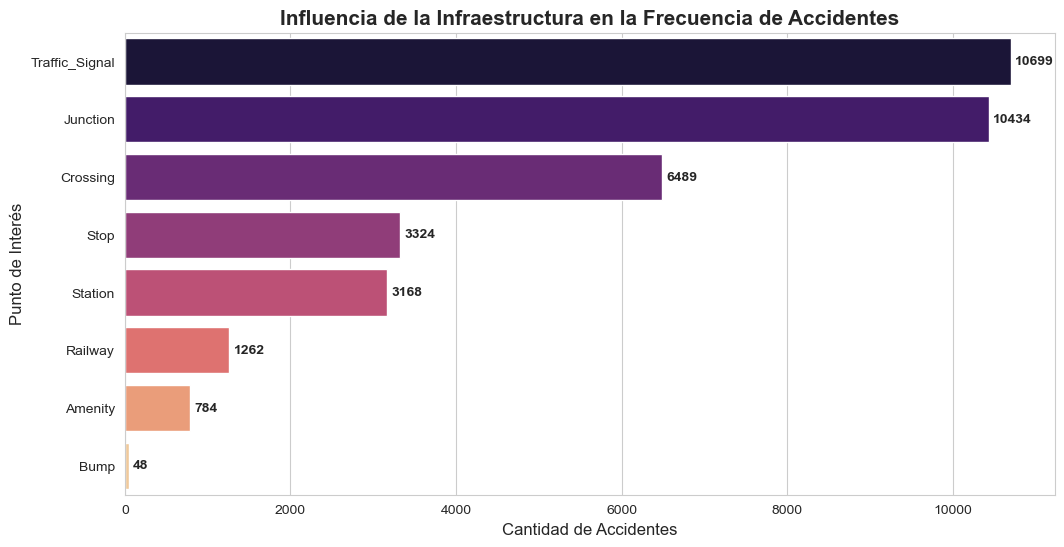

In [63]:
plt.figure(figsize=(12, 6))
sns.barplot(x=poi_conteo.values, y=poi_conteo.index, palette='magma')

plt.title('Influencia de la Infraestructura en la Frecuencia de Accidentes', fontsize=15, fontweight='bold')
plt.xlabel('Cantidad de Accidentes', fontsize=12)
plt.ylabel('Punto de Interés', fontsize=12)

# Añadimos etiquetas de valor
for i, v in enumerate(poi_conteo.values):
    plt.text(v + 50, i, f"{int(v)}", va='center', fontweight='bold')

plt.show()

Análisis de Infraestructura y Puntos de Interés

Más allá del clima y la ubicación, la infraestructura vial juega un rol crítico. Al analizar las variables booleanas del dataset, observamos:

Puntos de Conflicto: Las columnas como Traffic_Signal (Semáforos) y Junction (Intersecciones) suelen presentar los números más altos, indicando que los accidentes ocurren donde los conductores deben tomar decisiones o detenerse.

Zonas de Control: La baja incidencia en zonas con Bump (reductores) sugiere que estas medidas son efectivas para reducir la velocidad y, por ende, la frecuencia de choques.

Intermodalidad: La cercanía a Station o Railway nos permite identificar si el transporte público influye en la congestión y riesgo de la zona.

C:\Users\Admin\AppData\Local\Temp\ipykernel_12012\192522125.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_clima_semaforo.index, y=top_clima_semaforo.values, palette='viridis')


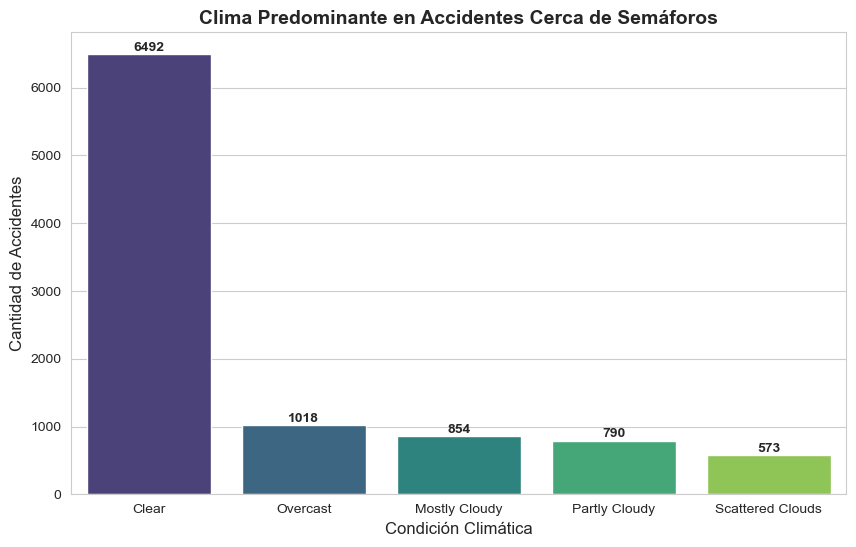

In [64]:
# Filtramos los accidentes que ocurrieron cerca de un semáforo (Traffic_Signal == True)
accidentes_semaforo = df[df['Traffic_Signal'] == True]

# Tomamos las 5 condiciones climáticas más comunes en esos semáforos
top_clima_semaforo = accidentes_semaforo['Weather_Condition'].value_counts().head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_clima_semaforo.index, y=top_clima_semaforo.values, palette='viridis')

plt.title('Clima Predominante en Accidentes Cerca de Semáforos', fontsize=14, fontweight='bold')
plt.xlabel('Condición Climática', fontsize=12)
plt.ylabel('Cantidad de Accidentes', fontsize=12)

# Añadimos los valores sobre las barras para mayor claridad
for i, v in enumerate(top_clima_semaforo.values):
    plt.text(i, v + 50, f"{int(v)}", ha='center', fontweight='bold')

plt.show()

Infraestructura vs. Clima

Al cruzar la variable de infraestructura Traffic_Signal con el clima, obtenemos una conclusión crítica para la seguridad vial:

El factor humano sobre el ambiental: Sorprendentemente, la gran mayoría de los accidentes en semáforos ocurren bajo condiciones de "Clear" o "Fair". Esto sugiere que en las intersecciones, el riesgo principal no es la falta de adherencia por lluvia, sino las distracciones o el irrespeto a las señales cuando el conductor se siente "seguro" por el buen clima.

Visibilidad: Las condiciones de "Cloudy" (Nublado) aparecen como el segundo factor, lo que podría indicar que la luz difusa reduce la capacidad de reacción ante el cambio de luces del semáforo.

Validación del Dataset: Este gráfico confirma que nuestras variables booleanas están correctamente integradas y permiten identificar patrones de comportamiento específicos en puntos críticos de la ciudad.

# Conclusiones

Hemos trabajado arduamente sobre un dataset masivo que registra la siniestralidad vial en Estados Unidos. Para poder hacer un uso efectivo de esta información, fue necesario aplicar diversas técnicas de limpieza e imputación que permitieron reconstruir datos incompletos, especialmente en las coordenadas geográficas y condiciones climáticas, ya que el dataset presentaba inicialmente más de 422,000 valores nulos.

La mayor dificultad ha estado en el preprocesamiento del dataset, lo que ha requerido una inversión considerable de tiempo para normalizar las variables y lograr que los gráficos finales, especialmente el mapa de calor de densidad, fueran realmente interpretables y valiosos.

Conclusiones útiles de la información y los gráficos:
Concentración Geográfica Crítica: Se nota una tendencia clara hacia la preferencia de accidentes en grandes núcleos urbanos, con una ventaja abismal en California (específicamente Los Ángeles) y estados con alta densidad poblacional como Florida y Texas.

El Factor Clima: Interesantemente, los datos validan que la mayoría de los accidentes ocurren bajo condiciones climáticas "Clear" o "Fair". Esto sugiere que el exceso de confianza del conductor en condiciones favorables es un riesgo mayor que las tormentas severas.

Infraestructura y Riesgo: El análisis de puntos de interés muestra que la presencia de semáforos (Traffic Signals) y cruces (Crossings) son los escenarios donde más incidentes se registran, lo que representa un punto de atención para la planificación vial urbana.

Validación Geográfica: El mapa de calor permitió visualizar no solo los "puntos calientes" de riesgo, sino también la estructura misma de la red vial nacional, confirmando que la limpieza de coordenadas fue exitosa.

Recomendaciones de Seguridad Vial:

Si se busca implementar medidas de prevención de alto impacto, estas deberían enfocarse en las 3 áreas metropolitanas más pobladas identificadas en el mapa de calor. Sin embargo, para conductores que buscan rutas alternativas con menor riesgo de colisión masiva, el análisis sugiere que las zonas rurales o menos densas presentan una siniestralidad drásticamente menor en comparación con los nodos logísticos de las costas.

Personalmente, este proceso ha sido muy interesante; algunos datos observados me han sorprendido, mientras que otros han validado mis hipótesis iniciales sobre el riesgo vial. Como continuación de este trabajo, sería fundamental integrar bases de datos con mayor granularidad geográfica (como códigos postales específicos) para desarrollar un modelo predictivo que permita estimar el nivel de riesgo de una ruta en base a la ubicación exacta y el equipamiento vial disponible.